## MSc Artificial Intelligence - Masters Project

## Farah Iqbal - S08431208

# Multimodal Data Integration and Exploratory Analysis

### Research Objective

The purpose of this notebook is to merge the cleaned clinical dataset from Notebook 1 with the MRI-derived biomarker dataset from Notebook 2.

This creates the multimodal dataset required for disability severity prediction in Multiple Sclerosis. The merged dataset will combine clinical features such as age, disease duration, neurological findings and EDSS scores with MRI-derived features such as lesion volume, lesion count and lesion size measurements.

This notebook will also explore relationships between clinical variables and MRI biomarkers before machine learning models are developed in the next stage.

## Notebook 3 Structure

- Load the cleaned clinical dataset
- Load the MRI feature dataset
- Check patient IDs and dataset dimensions
- Merge clinical and MRI features
- Check missing values and duplicates
- Explore the merged multimodal dataset
- Analyse relationships between MRI biomarkers and EDSS
- Generate correlation heatmaps and visualisations
- Prepare the final modelling dataset
- Export the multimodal dataset for machine learning

Import Libraries

In [ ]:
# Import required libraries

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns in dataframes
pd.set_option("display.max_columns", None)

# Set default figure size
plt.rcParams["figure.figsize"] = (8, 5)

Mount Google Drive

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Set File Paths

In [ ]:
# Define paths to the cleaned clinical dataset and MRI feature dataset

clinical_path = "/content/drive/MyDrive/MS_Dissertation/Outputs/cleaned_clinical_data.csv"

mri_path = "/content/drive/MyDrive/MS_Dissertation/Outputs/mri_features_flair.csv"

# Double Check whether the files exist
print("Clinical file exists:", os.path.exists(clinical_path))
print("MRI file exists:", os.path.exists(mri_path))

Clinical file exists: True
MRI file exists: True


Load the Datasets

In [ ]:
# Load the cleaned clinical dataset from Notebook 1
clinical_df = pd.read_csv(clinical_path)

# Load the MRI feature dataset from Notebook 2
mri_df = pd.read_csv(mri_path)

# Display first few rows of each dataset
display(clinical_df.head())
display(mri_df.head())

,ID,Gender,Age,Age_of_onset,EDSS,MRI_EDSS_Time_Difference_Under_2_Months,Types_of_Medicines,Presenting_Symptom,Co_morbidity,Pyramidal,Cerebella,Brain_stem,Sensory,Sphincters,Visual,Mental,Speech,Motor_System,Sensory_System,Coordination,Gait,Bowel_and_bladder_function,Mobility,Mental_State,Optic_discs,Fields,Nystagmus,Ocular_Movement,Swallowing,Disease_Duration,EDSS_Category,Total_Abnormal_Neuro_Findings
0,1,F,56,43,3.0,No,Gelenia,Motor,No,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,1,0,0,13,Moderate,4
1,2,F,29,19,1.5,No,Gelenia,Sensory,No,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,10,Low,3
2,3,F,15,8,4.0,No,Tysabri,Motor,No,1,1,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0,7,Moderate,6
3,4,F,24,20,6.0,No,Tysabri,Sensory,No,1,1,1,0,1,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,4,High,7
4,5,F,33,31,0.0,No,Avonex,Pain,No,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,2,Low,1


,Patient_ID,Lesion_Voxels,Lesion_Volume_mm3,Lesion_Count,Average_Lesion_Size,Largest_Lesion_Size,Smallest_Lesion_Size,Small_Lesions,Medium_Lesions,Large_Lesions
0,1,776,776.0,52,14.923077,68,2,25,26,1
1,2,2485,2485.0,33,75.303030,629,6,4,20,9
2,3,2273,2273.0,65,34.969231,188,1,14,35,16
3,4,4906,4906.0,21,233.619048,2194,3,6,9,6
4,5,2109,2109.0,59,35.745763,257,5,9,39,11


## Check Dataset Dimensions and Columns

Before merging the datasets, the structure of both datasets is checked. This helps confirm that the clinical and MRI feature files have loaded correctly and that both contain patient identifiers for merging.

Check Dataset Shape and Columns

In [ ]:
print("Clinical dataset shape:", clinical_df.shape)
print("MRI feature dataset shape:", mri_df.shape)

print("\nClinical columns:")
print(clinical_df.columns.tolist())

print("\nMRI feature columns:")
print(mri_df.columns.tolist())

Clinical dataset shape: (60, 32)
MRI feature dataset shape: (60, 10)

Clinical columns:
['ID', 'Gender', 'Age', 'Age_of_onset', 'EDSS', 'MRI_EDSS_Time_Difference_Under_2_Months', 'Types_of_Medicines', 'Presenting_Symptom', 'Co_morbidity', 'Pyramidal', 'Cerebella', 'Brain_stem', 'Sensory', 'Sphincters', 'Visual', 'Mental', 'Speech', 'Motor_System', 'Sensory_System', 'Coordination', 'Gait', 'Bowel_and_bladder_function', 'Mobility', 'Mental_State', 'Optic_discs', 'Fields', 'Nystagmus', 'Ocular_Movement', 'Swallowing', 'Disease_Duration', 'EDSS_Category', 'Total_Abnormal_Neuro_Findings']

MRI feature columns:
['Patient_ID', 'Lesion_Voxels', 'Lesion_Volume_mm3', 'Lesion_Count', 'Average_Lesion_Size', 'Largest_Lesion_Size', 'Smallest_Lesion_Size', 'Small_Lesions', 'Medium_Lesions', 'Large_Lesions']


Check Patient ID Columns

In [ ]:
# Display the first few Patient IDs from both datasets
print("Clinical Patient IDs:")
print(clinical_df["ID"].head())

print("\nMRI Patient IDs:")
print(mri_df["Patient_ID"].head())

Clinical Patient IDs:
0    1
1    2
2    3
3    4
4    5
Name: ID, dtype: int64

MRI Patient IDs:
0    1
1    2
2    3
3    4
4    5
Name: Patient_ID, dtype: int64


Rename Clinical ID Column

In [ ]:
# Rename clinical ID column so both datasets use the same patient identifier
clinical_df = clinical_df.rename(columns={"ID": "Patient_ID"})

# Check the updated column names
clinical_df.head()

,Patient_ID,Gender,Age,Age_of_onset,EDSS,MRI_EDSS_Time_Difference_Under_2_Months,Types_of_Medicines,Presenting_Symptom,Co_morbidity,Pyramidal,Cerebella,Brain_stem,Sensory,Sphincters,Visual,Mental,Speech,Motor_System,Sensory_System,Coordination,Gait,Bowel_and_bladder_function,Mobility,Mental_State,Optic_discs,Fields,Nystagmus,Ocular_Movement,Swallowing,Disease_Duration,EDSS_Category,Total_Abnormal_Neuro_Findings
0,1,F,56,43,3.0,No,Gelenia,Motor,No,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,1,0,0,13,Moderate,4
1,2,F,29,19,1.5,No,Gelenia,Sensory,No,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,10,Low,3
2,3,F,15,8,4.0,No,Tysabri,Motor,No,1,1,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0,7,Moderate,6
3,4,F,24,20,6.0,No,Tysabri,Sensory,No,1,1,1,0,1,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,4,High,7
4,5,F,33,31,0.0,No,Avonex,Pain,No,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,2,Low,1


Check Duplicate Patient IDs

In [ ]:
# Check for duplicate Patient IDs in each dataset
print("Duplicate Patient IDs in clinical dataset:", clinical_df["Patient_ID"].duplicated().sum())
print("Duplicate Patient IDs in MRI dataset:", mri_df["Patient_ID"].duplicated().sum())

Duplicate Patient IDs in clinical dataset: 0
Duplicate Patient IDs in MRI dataset: 0


Check Patient ID Overlap

In [ ]:
# Check how many patients appear in both datasets
clinical_ids = set(clinical_df["Patient_ID"])
mri_ids = set(mri_df["Patient_ID"])

common_ids = clinical_ids.intersection(mri_ids)

print("Clinical patients:", len(clinical_ids))
print("MRI patients:", len(mri_ids))
print("Patients in both datasets:", len(common_ids))

print("\nClinical IDs missing from MRI dataset:")
print(sorted(clinical_ids - mri_ids))

print("\nMRI IDs missing from clinical dataset:")
print(sorted(mri_ids - clinical_ids))

Clinical patients: 60
MRI patients: 60
Patients in both datasets: 60

Clinical IDs missing from MRI dataset:
[]

MRI IDs missing from clinical dataset:
[]


## Merge Clinical and MRI Features

The cleaned clinical dataset and MRI-derived biomarker dataset are merged using the Patient_ID column. This creates the multimodal dataset that will later be used for machine learning models.

Merge Datasets

In [ ]:
# Merge clinical data with MRI features using Patient_ID
multimodal_df = pd.merge(
    clinical_df,
    mri_df,
    on="Patient_ID",
    how="inner"
)

# Display merged dataset
print("Merged multimodal dataset shape:", multimodal_df.shape)
multimodal_df.head()

Merged multimodal dataset shape: (60, 41)


,Patient_ID,Gender,Age,Age_of_onset,EDSS,MRI_EDSS_Time_Difference_Under_2_Months,Types_of_Medicines,Presenting_Symptom,Co_morbidity,Pyramidal,Cerebella,Brain_stem,Sensory,Sphincters,Visual,Mental,Speech,Motor_System,Sensory_System,Coordination,Gait,Bowel_and_bladder_function,Mobility,Mental_State,Optic_discs,Fields,Nystagmus,Ocular_Movement,Swallowing,Disease_Duration,EDSS_Category,Total_Abnormal_Neuro_Findings,Lesion_Voxels,Lesion_Volume_mm3,Lesion_Count,Average_Lesion_Size,Largest_Lesion_Size,Smallest_Lesion_Size,Small_Lesions,Medium_Lesions,Large_Lesions
0,1,F,56,43,3.0,No,Gelenia,Motor,No,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,1,0,0,13,Moderate,4,776,776.0,52,14.923077,68,2,25,26,1
1,2,F,29,19,1.5,No,Gelenia,Sensory,No,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,10,Low,3,2485,2485.0,33,75.303030,629,6,4,20,9
2,3,F,15,8,4.0,No,Tysabri,Motor,No,1,1,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0,7,Moderate,6,2273,2273.0,65,34.969231,188,1,14,35,16
3,4,F,24,20,6.0,No,Tysabri,Sensory,No,1,1,1,0,1,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,4,High,7,4906,4906.0,21,233.619048,2194,3,6,9,6
4,5,F,33,31,0.0,No,Avonex,Pain,No,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,2,Low,1,2109,2109.0,59,35.745763,257,5,9,39,11


Check Missing Values After Merge

In [ ]:
# Check missing values in the merged dataset
missing_values = multimodal_df.isnull().sum()

# Display only columns with missing values
missing_values[missing_values > 0]

,0


Summary Statistics

In [ ]:
# Summary statistics for the multimodal dataset
multimodal_df.describe()

,Patient_ID,Age,Age_of_onset,EDSS,Pyramidal,Cerebella,Brain_stem,Sensory,Sphincters,Visual,Mental,Speech,Motor_System,Sensory_System,Coordination,Gait,Bowel_and_bladder_function,Mobility,Mental_State,Optic_discs,Fields,Nystagmus,Ocular_Movement,Swallowing,Disease_Duration,Total_Abnormal_Neuro_Findings,Lesion_Voxels,Lesion_Volume_mm3,Lesion_Count,Average_Lesion_Size,Largest_Lesion_Size,Smallest_Lesion_Size,Small_Lesions,Medium_Lesions,Large_Lesions
count,60.000000,60.0000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.0,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.00000,60.000000,60.000000,60.000000,60.000000
mean,30.500000,32.6500,29.766667,2.266667,0.516667,0.283333,0.083333,0.300000,0.150000,0.283333,0.033333,0.100000,0.583333,0.316667,0.283333,0.283333,0.150000,0.066667,0.050000,0.366667,0.0,0.116667,0.033333,0.050000,2.883333,4.050000,8086.083333,8086.083333,44.233333,206.022490,2455.15000,5.083333,9.916667,17.783333,16.533333
std,17.464249,12.1304,11.009036,1.595722,0.503939,0.454420,0.278718,0.462125,0.360085,0.454420,0.181020,0.302532,0.497167,0.469102,0.454420,0.454420,0.360085,0.251549,0.219784,0.485961,0.0,0.323732,0.181020,0.219784,4.239010,2.389419,12724.711405,12724.711405,41.387940,306.784186,5080.93112,13.754866,24.041836,17.936887,16.868853
min,1.000000,15.0000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,-2.000000,0.000000,324.000000,324.000000,2.000000,7.653509,47.00000,1.000000,0.000000,0.000000,0.000000
25%,15.750000,20.0000,19.750000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,2.000000,1741.250000,1741.250000,21.750000,49.717672,307.50000,1.000000,2.000000,7.750000,7.000000
50%,30.500000,33.0000,30.500000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,1.500000,4.000000,3300.500000,3300.500000,32.500000,100.423828,625.00000,2.000000,4.500000,14.000000,12.000000
75%,45.250000,42.2500,40.000000,3.500000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.0,0.000000,0.000000,0.000000,4.000000,6.000000,7703.250000,7703.250000,51.250000,240.754831,1972.00000,4.000000,8.000000,20.250000,17.250000
max,60.000000,56.0000,52.000000,6.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,21.000000,10.000000,60999.000000,60999.000000,228.000000,1783.259259,29363.00000,104.000000,178.000000,111.000000,101.000000


## Multimodal Exploratory Analysis

The following section explores relationships between clinical variables and MRI-derived biomarkers. This is important because it helps identify whether imaging features such as lesion volume and lesion count show meaningful relationships with disability severity.

Select Key Numeric Features

In [ ]:
# Select key numerical features for analysis

key_features = [
    "Age",
    "Age of onset",
    "EDSS",
    "Disease_Duration",
    "Total_Abnormal_Neuro_Findings",
    "Lesion_Volume_mm3",
    "Lesion_Count",
    "Average_Lesion_Size",
    "Largest_Lesion_Size"
]

# Keep only columns that exist in the dataset
key_features = [col for col in key_features if col in multimodal_df.columns]

print("Selected numerical features for analysis:\n")

for feature in key_features:
    print("-", feature)

Selected numerical features for analysis:

- Age
- EDSS
- Disease_Duration
- Total_Abnormal_Neuro_Findings
- Lesion_Volume_mm3
- Lesion_Count
- Average_Lesion_Size
- Largest_Lesion_Size


Correlation Matrix

In [ ]:
# Create correlation matrix for selected features
correlation_matrix = multimodal_df[key_features].corr()

correlation_matrix

,Age,EDSS,Disease_Duration,Total_Abnormal_Neuro_Findings,Lesion_Volume_mm3,Lesion_Count,Average_Lesion_Size,Largest_Lesion_Size
Age,1.000000,0.212425,0.427034,0.112889,0.087252,-0.251581,0.289681,0.225525
EDSS,0.212425,1.000000,0.068572,0.674348,0.050872,-0.154940,0.235889,0.160732
Disease_Duration,0.427034,0.068572,1.000000,0.017319,-0.037563,-0.134706,0.038647,0.049712
Total_Abnormal_Neuro_Findings,0.112889,0.674348,0.017319,1.000000,-0.017196,0.001423,0.116197,0.055564
Lesion_Volume_mm3,0.087252,0.050872,-0.037563,-0.017196,1.000000,0.276526,0.812089,0.899353
Lesion_Count,-0.251581,-0.154940,-0.134706,0.001423,0.276526,1.000000,-0.082253,0.112202
Average_Lesion_Size,0.289681,0.235889,0.038647,0.116197,0.812089,-0.082253,1.000000,0.933368
Largest_Lesion_Size,0.225525,0.160732,0.049712,0.055564,0.899353,0.112202,0.933368,1.000000


Correlation Heatmap

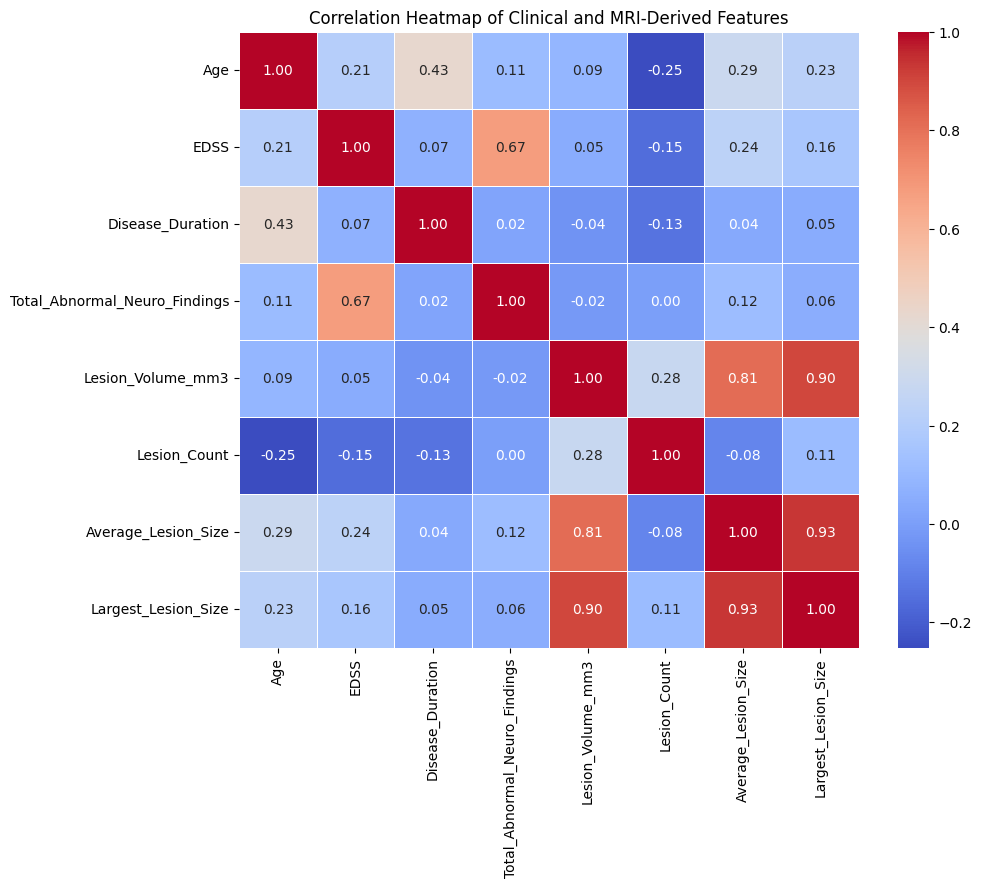

In [ ]:
# Plot heatmap of correlations between clinical and MRI features

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Clinical and MRI-Derived Features")
plt.show()

Correlation with EDSS

In [ ]:
# Rank feature correlations with EDSS
edss_correlations = correlation_matrix["EDSS"].drop("EDSS").sort_values(ascending=False)

edss_correlation_table = pd.DataFrame({
    "Feature": edss_correlations.index,
    "Correlation_with_EDSS": edss_correlations.values
})

edss_correlation_table

,Feature,Correlation_with_EDSS
0,Total_Abnormal_Neuro_Findings,0.674348
1,Average_Lesion_Size,0.235889
2,Age,0.212425
3,Largest_Lesion_Size,0.160732
4,Disease_Duration,0.068572
5,Lesion_Volume_mm3,0.050872
6,Lesion_Count,-0.154940


Bar Chart of EDSS Correlations

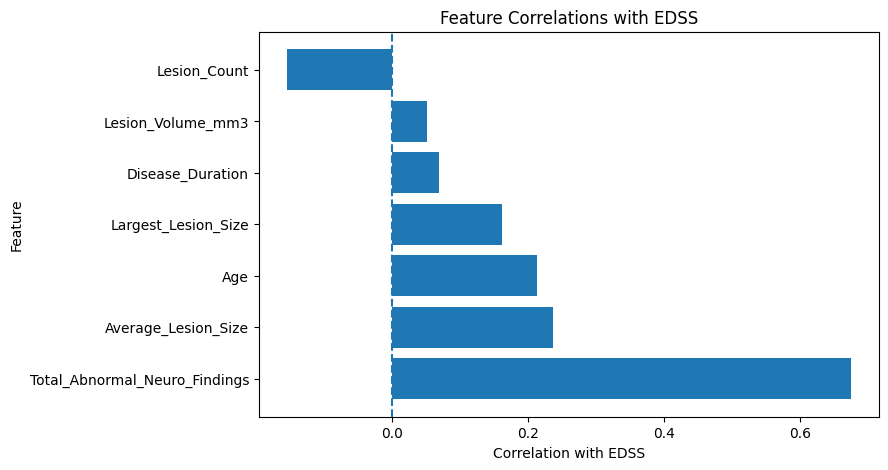

In [ ]:
# Plot correlations with EDSS

plt.figure(figsize=(8, 5))

plt.barh(
    edss_correlation_table["Feature"],
    edss_correlation_table["Correlation_with_EDSS"]
)

plt.xlabel("Correlation with EDSS")
plt.ylabel("Feature")
plt.title("Feature Correlations with EDSS")
plt.axvline(0, linestyle="--")

plt.show()

## MRI Biomarkers and Disability Severity

The following visualisations explore how MRI-derived biomarkers relate to EDSS scores. EDSS is used as the main clinical indicator of disability severity in this project.

Lesion Volume vs EDSS

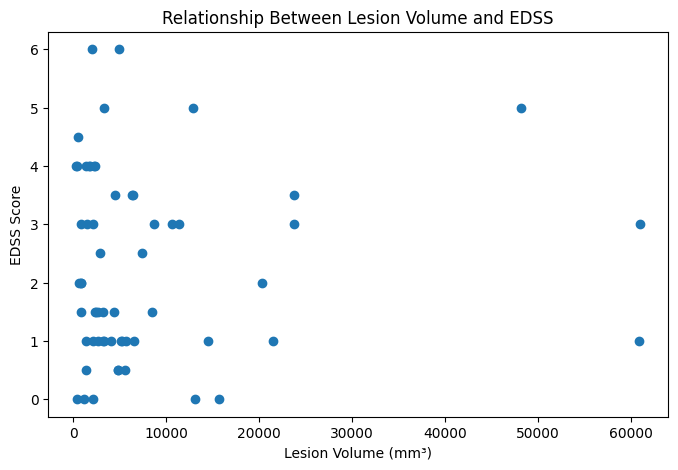

In [ ]:
# Scatter plot of lesion volume against EDSS

plt.figure(figsize=(8, 5))

plt.scatter(
    multimodal_df["Lesion_Volume_mm3"],
    multimodal_df["EDSS"]
)

plt.xlabel("Lesion Volume (mm³)")
plt.ylabel("EDSS Score")
plt.title("Relationship Between Lesion Volume and EDSS")

plt.show()

Lesion Count vs EDSS

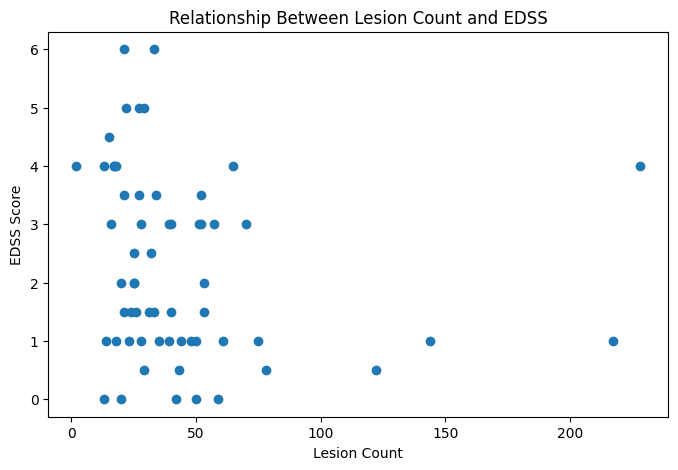

In [ ]:
# Scatter plot of lesion count against EDSS

plt.figure(figsize=(8, 5))

plt.scatter(
    multimodal_df["Lesion_Count"],
    multimodal_df["EDSS"]
)

plt.xlabel("Lesion Count")
plt.ylabel("EDSS Score")
plt.title("Relationship Between Lesion Count and EDSS")

plt.show()

Largest Lesion Size vs EDSS

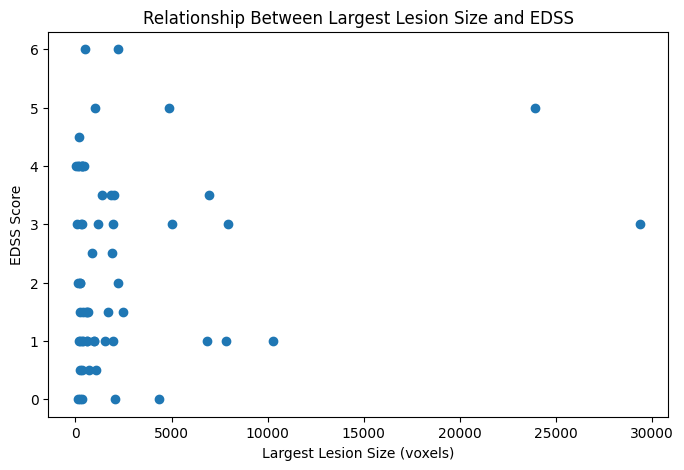

In [ ]:
# Scatter plot of largest lesion size against EDSS

plt.figure(figsize=(8, 5))

plt.scatter(
    multimodal_df["Largest_Lesion_Size"],
    multimodal_df["EDSS"]
)

plt.xlabel("Largest Lesion Size (voxels)")
plt.ylabel("EDSS Score")
plt.title("Relationship Between Largest Lesion Size and EDSS")

plt.show()

Disease Duration vs EDSS

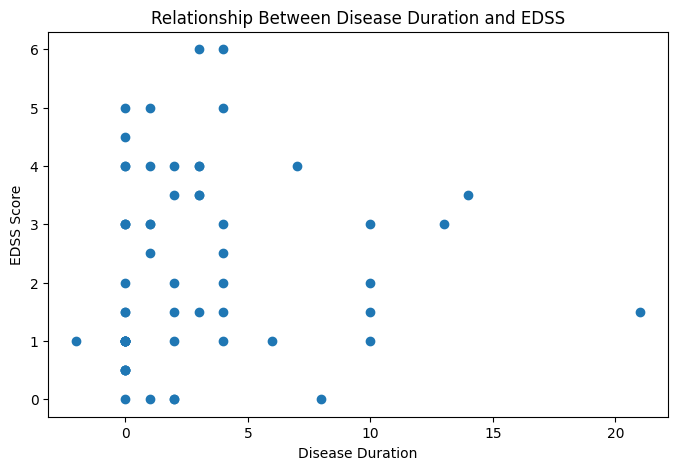

In [ ]:
# Scatter plot of disease duration against EDSS

plt.figure(figsize=(8, 5))

plt.scatter(
    multimodal_df["Disease_Duration"],
    multimodal_df["EDSS"]
)

plt.xlabel("Disease Duration")
plt.ylabel("EDSS Score")
plt.title("Relationship Between Disease Duration and EDSS")

plt.show()

## Disability Category Analysis

This section compares MRI biomarkers across EDSS disability categories. This helps explore whether patients with higher disability levels also show higher lesion volume, lesion count or lesion size.

Check EDSS Category Column

In [ ]:
# Check available columns related to EDSS categories
[col for col in multimodal_df.columns if "EDSS" in col or "Disability" in col]

['EDSS', 'MRI_EDSS_Time_Difference_Under_2_Months', 'EDSS_Category']

Create EDSS Categories

In [ ]:
# Create EDSS disability categories

if "EDSS_Category" not in multimodal_df.columns:

    def classify_edss(score):
        if score <= 2.5:
            return "Low"
        elif score <= 5.5:
            return "Moderate"
        else:
            return "High"

    multimodal_df["EDSS_Category"] = multimodal_df["EDSS"].apply(classify_edss)

# Check category counts
multimodal_df["EDSS_Category"].value_counts()

,count
EDSS_Category,
Low,35
Moderate,23
High,2


## Class Balance Observation

The EDSS category distribution shows that the High disability group contains very few patients compared with the Low and Moderate groups. This will be considered during the modelling stage, as strong class imbalance can affect model performance and make classification results less reliable.

For this reason, the modelling notebook may compare different approaches, such as using EDSS as a regression target or combining categories for a binary classification task.

Boxplot - Lesion Volume by EDSS Category

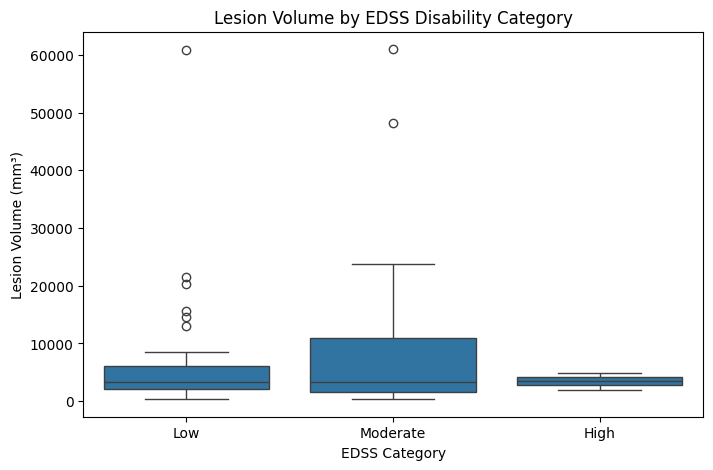

In [ ]:
category_order = ["Low", "Moderate", "High"]

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=multimodal_df,
    x="EDSS_Category",
    y="Lesion_Volume_mm3",
    order=category_order
)

plt.xlabel("EDSS Category")
plt.ylabel("Lesion Volume (mm³)")
plt.title("Lesion Volume by EDSS Disability Category")

plt.show()

Boxplot - Lesion Count by EDSS Category

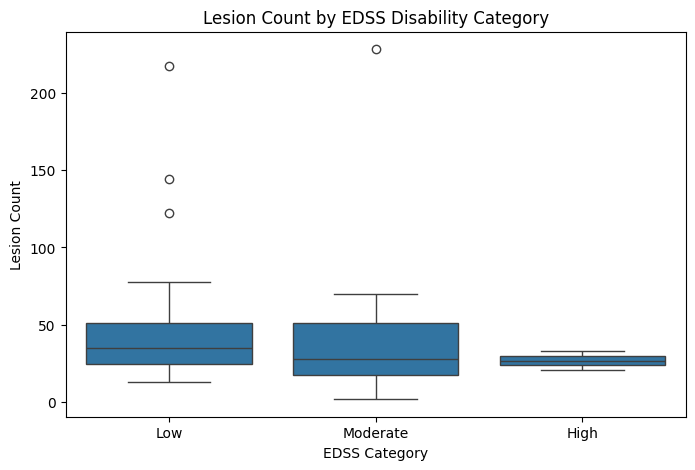

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=multimodal_df,
    x="EDSS_Category",
    y="Lesion_Count",
    order=category_order
)

plt.xlabel("EDSS Category")
plt.ylabel("Lesion Count")
plt.title("Lesion Count by EDSS Disability Category")

plt.show()

Mean MRI Features by EDSS Category

In [ ]:
# Calculate mean MRI biomarkers by EDSS disability category

mri_summary_by_category = multimodal_df.groupby("EDSS_Category")[
    [
        "Lesion_Volume_mm3",
        "Lesion_Count",
        "Average_Lesion_Size",
        "Largest_Lesion_Size"
    ]
].mean().reindex(category_order)

mri_summary_by_category

,Lesion_Volume_mm3,Lesion_Count,Average_Lesion_Size,Largest_Lesion_Size
EDSS_Category,,,,
Low,6929.057143,47.428571,137.967741,1556.314286
Moderate,10249.565217,40.869565,314.704032,3920.391304
High,3454.000000,27.000000,147.142857,1334.500000


Bar Chart - Mean Lesion Volume by EDSS Category

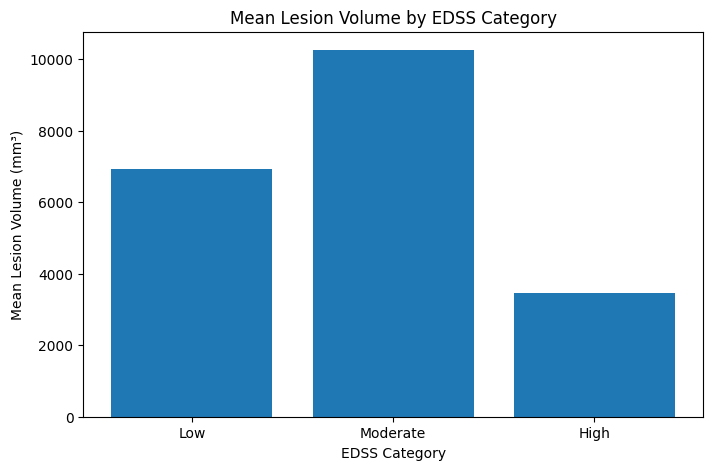

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    mri_summary_by_category.index,
    mri_summary_by_category["Lesion_Volume_mm3"]
)

plt.xlabel("EDSS Category")
plt.ylabel("Mean Lesion Volume (mm³)")
plt.title("Mean Lesion Volume by EDSS Category")

plt.show()

Bar Chart - Mean Lesion Count by EDSS Category

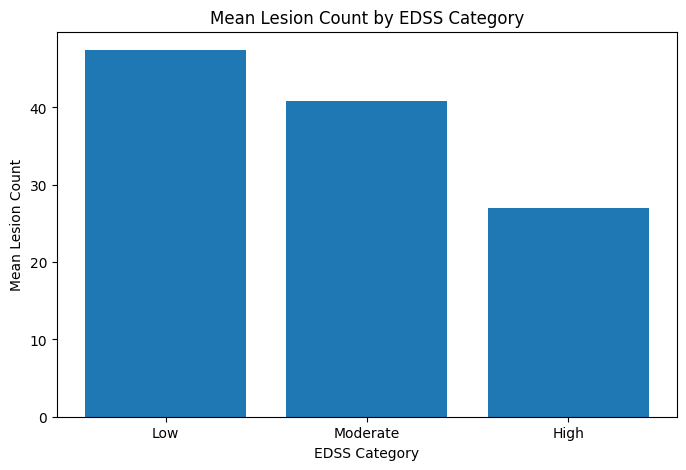

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    mri_summary_by_category.index,
    mri_summary_by_category["Lesion_Count"]
)

plt.xlabel("EDSS Category")
plt.ylabel("Mean Lesion Count")
plt.title("Mean Lesion Count by EDSS Category")

plt.show()

## Pairwise Feature Relationships

A pairplot is used to visually explore relationships between selected clinical and MRI-derived features. This can help identify patterns that may be useful for later machine learning modelling.

Pairplot of Key Features

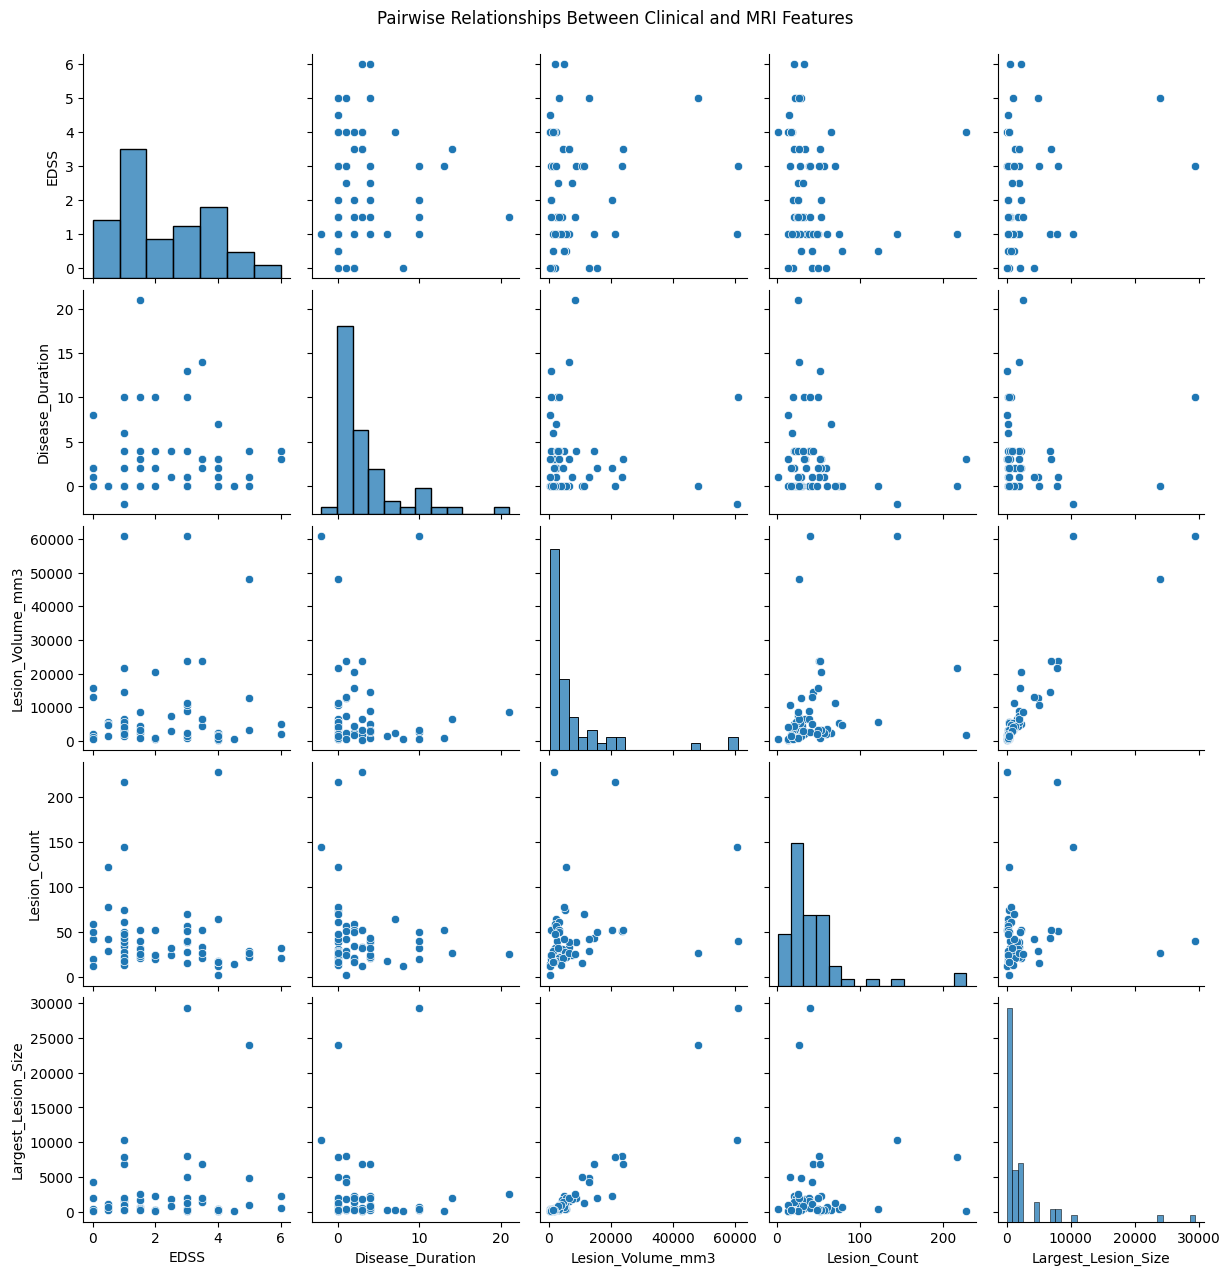

In [ ]:
# Create pairplot for selected key features

pairplot_features = [
    "EDSS",
    "Disease_Duration",
    "Lesion_Volume_mm3",
    "Lesion_Count",
    "Largest_Lesion_Size"
]

pairplot_features = [col for col in pairplot_features if col in multimodal_df.columns]

sns.pairplot(
    multimodal_df[pairplot_features],
    diag_kind="hist"
)

plt.suptitle("Pairwise Relationships Between Clinical and MRI Features", y=1.02)

plt.show()

## Prepare Final Modelling Dataset

Before machine learning modelling, the final dataset is checked and prepared. The aim is to ensure that the target variable and predictor features are clearly defined.

Define Target and Feature Columns

In [ ]:
# Define target variable
target_column = "EDSS_Category"

# Drop columns that should not be used as model input
columns_to_drop = [
    "EDSS",
    "EDSS_Category"
]

# Keep Patient_ID for tracking but do not use it for modelling later
feature_columns = [
    col for col in multimodal_df.columns
    if col not in columns_to_drop
]

print("Target column:", target_column)
print("Number of feature columns:", len(feature_columns))
print("Feature columns:")
print(feature_columns)

Target column: EDSS_Category
Number of feature columns: 39
Feature columns:
['Patient_ID', 'Gender', 'Age', 'Age_of_onset', 'MRI_EDSS_Time_Difference_Under_2_Months', 'Types_of_Medicines', 'Presenting_Symptom', 'Co_morbidity', 'Pyramidal', 'Cerebella', 'Brain_stem', 'Sensory', 'Sphincters', 'Visual', 'Mental', 'Speech', 'Motor_System', 'Sensory_System', 'Coordination', 'Gait', 'Bowel_and_bladder_function', 'Mobility', 'Mental_State', 'Optic_discs', 'Fields', 'Nystagmus', 'Ocular_Movement', 'Swallowing', 'Disease_Duration', 'Total_Abnormal_Neuro_Findings', 'Lesion_Voxels', 'Lesion_Volume_mm3', 'Lesion_Count', 'Average_Lesion_Size', 'Largest_Lesion_Size', 'Smallest_Lesion_Size', 'Small_Lesions', 'Medium_Lesions', 'Large_Lesions']


Final Missing Value Check

In [ ]:
# Check missing values in final multimodal dataset

final_missing_values = multimodal_df.isnull().sum()

final_missing_values[final_missing_values > 0]

,0


Export Multimodal Dataset

In [ ]:
output_folder = "/content/drive/MyDrive/MS_Dissertation/Outputs"

multimodal_output_path = os.path.join(output_folder, "multimodal_dataset.csv")

multimodal_df.to_csv(multimodal_output_path, index=False)

print("Multimodal dataset saved successfully.")
print(multimodal_output_path)

Multimodal dataset saved successfully.
/content/drive/MyDrive/MS_Dissertation/Outputs/multimodal_dataset.csv


Export Correlation Table

In [ ]:
correlation_output_path = os.path.join(output_folder, "edss_feature_correlations.csv")

edss_correlation_table.to_csv(correlation_output_path, index=False)

print("EDSS correlation table saved successfully.")
print(correlation_output_path)

EDSS correlation table saved successfully.
/content/drive/MyDrive/MS_Dissertation/Outputs/edss_feature_correlations.csv


## Summary

This notebook merged the cleaned clinical dataset with MRI-derived biomarkers to create a multimodal dataset for Multiple Sclerosis disability severity prediction.

The exploratory analysis examined relationships between clinical variables, MRI-derived biomarkers and EDSS disability severity. The generated figures and correlation outputs will support later dissertation writing and provide useful context before developing machine learning models.

The exported multimodal dataset will be used in the next notebook for predictive modelling.